In [131]:
import pandas as pd
import matplotlib.pyplot as plt

In [132]:
filename = '3_xhl_imputMF_150_interpolated1'
daily_df = pd.read_excel(f"F:\\geodata\\river_runoff_obs\\{filename}.xlsx")
# daily_df.head()
# F:\geodata\river_runoff_obs\3_xhl_imputMF_150_interpolated1.xlsx

In [133]:
daily_df['time'] = pd.to_datetime(daily_df['time'], format='%Y/%m/%d')
daily_df.set_index('time', inplace=True)
# daily_df.head()

In [134]:
month_df = daily_df[['pre',"tm","tmax",'tmin','runoff_mon']].resample('M').mean()
annual_se = month_df["runoff_mon"].resample('Y').sum()
annual_se.index = annual_se.index.year
annual_se=annual_se.rename("runoff_annual") 
# annual_se.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_96660\2252248184.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_df = daily_df[['pre',"tm","tmax",'tmin','runoff_mon']].resample('M').mean()
C:\Users\HP\AppData\Local\Temp\ipykernel_96660\2252248184.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_se = month_df["runoff_mon"].resample('Y').sum()


In [135]:
daily_df['year']=daily_df.index.year
# daily_df.head()

In [136]:
daily_df = daily_df.merge(annual_se, left_on='year', right_index=True)
# daily_df.head()

In [137]:
df_filtered = daily_df[daily_df['runoff_pre'].notna()]
df_filtered.head()

,ID,month,pre,tm,tmax,tmin,dis,runoff_mon,runoff_pre,mean_mon_runoff,year,runoff_annual
time,,,,,,,,,,,,
2012-01-01,18262,2012-01,0.014012,-13.678573,-5.918434,-19.384810,NaN,1096.389056,62.072368,36.546302,2012,55270.399991
2012-01-02,18263,2012-01,0.010840,-12.789660,-5.745827,-18.018904,NaN,1096.389056,62.040988,36.546302,2012,55270.399991
2012-01-03,18264,2012-01,0.018878,-14.357447,-7.537532,-19.630882,NaN,1096.389056,62.008025,36.546302,2012,55270.399991
2012-01-04,18265,2012-01,0.042975,-13.857157,-7.791222,-18.646173,NaN,1096.389056,61.986853,36.546302,2012,55270.399991
2012-01-05,18266,2012-01,0.037829,-14.607663,-7.078427,-19.754528,NaN,1096.389056,61.981184,36.546302,2012,55270.399991


In [138]:
# Group by the year and find the minimum value of 'dis' for each year
min_dis_per_year = daily_df.groupby(daily_df.index.year)['dis'].min()
min_dis_per_year

time
1962    16.8
1963    19.7
1964    19.6
1965    21.6
1966    21.7
        ... 
2018    23.8
2019    21.4
2020     NaN
2021     NaN
2022     NaN
Name: dis, Length: 61, dtype: float64

2012


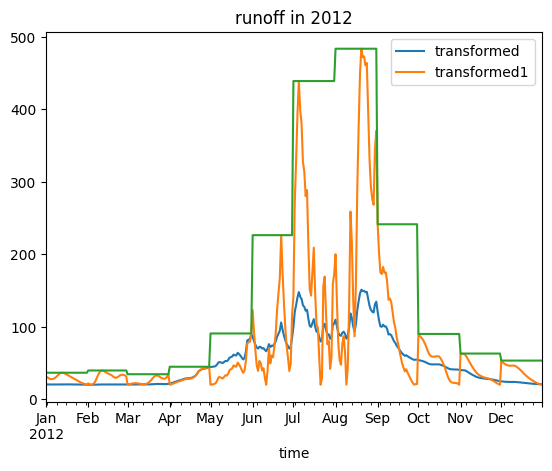

2013


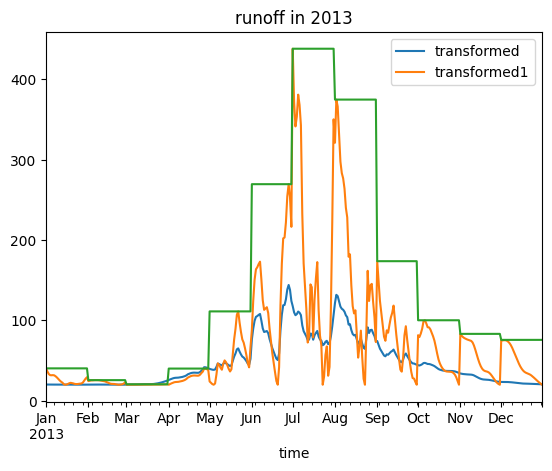

2014


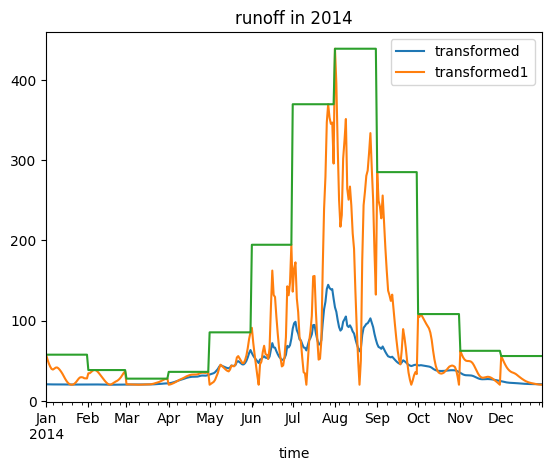

2015


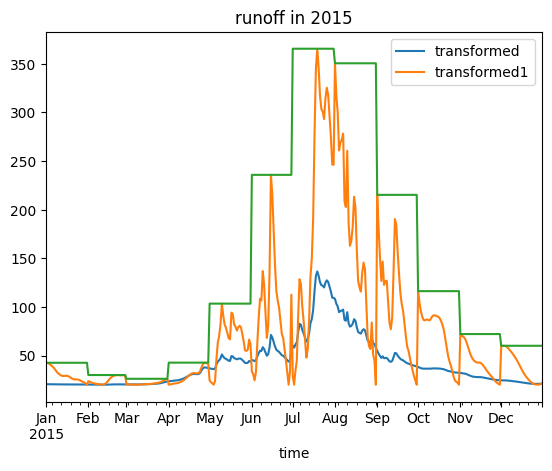

In [139]:
ann_grs = df_filtered.groupby('year')
for year, ann_gr in ann_grs:    
    print(year)
    ann_gr["minmax"] = (ann_gr.runoff_pre-ann_gr['runoff_pre'].min())/(ann_gr['runoff_pre'].max()-ann_gr['runoff_pre'].min())

    ann_gr["minmax"] = (ann_gr.runoff_pre - ann_gr['runoff_pre'].min()) / (
                ann_gr['runoff_pre'].max() - ann_gr['runoff_pre'].min())
    ann_gr.head()
    ann_gr['transformed'] = (ann_gr['runoff_annual'] / len(ann_gr) - 20) * ann_gr['minmax'] + 20
    mon_grs = ann_gr.groupby('month')
    for month, mon_gr in mon_grs:
        ann_gr["minmax"] = (ann_gr.runoff_pre - ann_gr['runoff_pre'].min()) / (
                    ann_gr['runoff_pre'].max() - ann_gr['runoff_pre'].min())
    
    
    # 2. Define a function for min-max scaling
    def min_max_scaling(group):
        return (group - group.min()) / (group.max() - group.min())
    
    
    # 3. Group by month and apply the scaling
    ann_gr['mon_min_max'] = ann_gr.groupby(ann_gr.index.month)['transformed'].transform(min_max_scaling)
    ann_gr['transformed1'] = (ann_gr['runoff_mon'] / 30 - 20) * ann_gr['mon_min_max'] + 20
    
    ann_gr[['transformed','transformed1']].plot()
    (ann_gr['runoff_mon']/30).plot()
    plt.title(f'runoff in {year}')
    plt.show()

2012


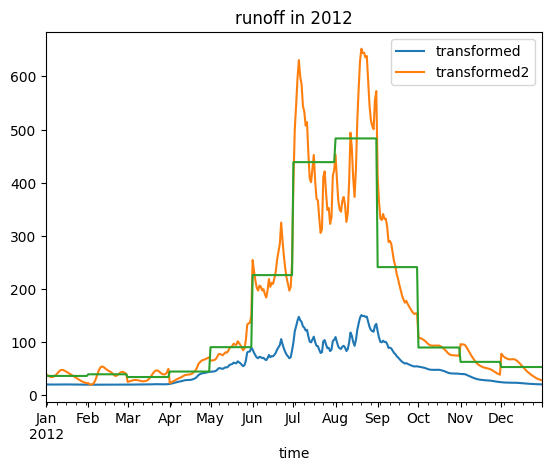

2013


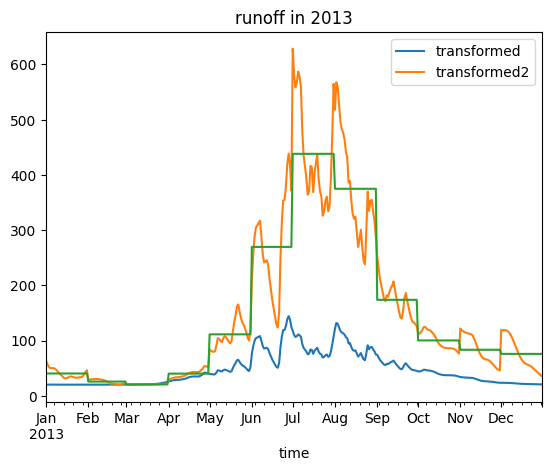

2014


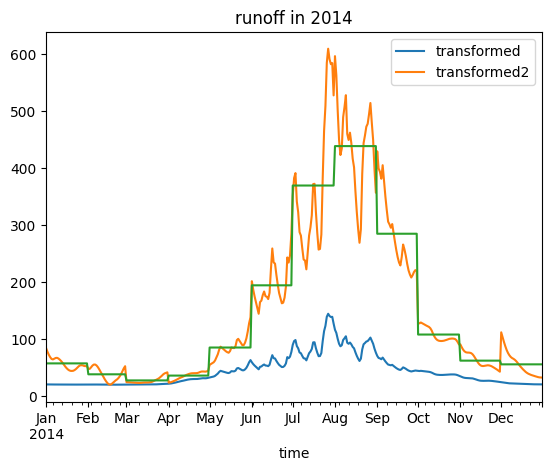

2015


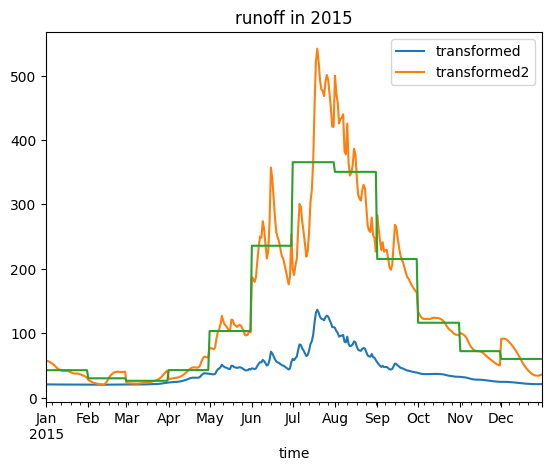

,ID,month,pre,tm,tmax,tmin,dis,runoff_mon,runoff_pre,mean_mon_runoff,year,runoff_annual,minmax,transformed,mon_min_max,monthly_mean_transformed,transformed2
time,,,,,,,,,,,,,,,,,
2015-01-01,19358,2015-01,0.014012,-11.110817,-2.768669,-17.472694,NaN,1277.354452,62.522669,42.578482,2015,49811.627665,0.004618,20.537828,1.000000,20.328525,56.963247
2015-01-02,19359,2015-01,0.010840,-11.069143,-3.398893,-17.283081,NaN,1277.354452,62.518811,42.578482,2015,49811.627665,0.004593,20.534898,0.992215,20.328525,56.761858
2015-01-03,19360,2015-01,0.018878,-10.275777,-1.207410,-16.616697,NaN,1277.354452,62.506735,42.578482,2015,49811.627665,0.004514,20.525724,0.967842,20.328525,56.131403
2015-01-04,19361,2015-01,0.042975,-11.053062,-5.557246,-16.624073,NaN,1277.354452,62.480618,42.578482,2015,49811.627665,0.004343,20.505885,0.915131,20.328525,54.767889
2015-01-05,19362,2015-01,0.037829,-10.719163,-4.904524,-14.812473,NaN,1277.354452,62.456855,42.578482,2015,49811.627665,0.004188,20.487834,0.867174,20.328525,53.527330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-27,19718,2015-12,0.099489,-8.352655,-1.578097,-13.545213,NaN,1801.476245,62.982406,60.049208,2015,49811.627665,0.007616,20.887057,0.003776,22.501455,34.202102
2015-12-28,19719,2015-12,0.074695,-9.967157,-2.579871,-15.674028,NaN,1801.476245,62.964515,60.049208,2015,49811.627665,0.007499,20.873466,0.000000,22.501455,33.984515
2015-12-29,19720,2015-12,0.052963,-10.764790,-2.291855,-16.796238,NaN,1801.476245,63.002059,60.049208,2015,49811.627665,0.007744,20.901986,0.007925,22.501455,34.441121


In [152]:
# make the monthly daily runoff's mean value is equal to month's
ann_grs = df_filtered.groupby('year')
for year, ann_gr in ann_grs:    
    print(year)
    ann_gr["minmax"] = (ann_gr.runoff_pre-ann_gr['runoff_pre'].min())/(ann_gr['runoff_pre'].max()-ann_gr['runoff_pre'].min())

    ann_gr["minmax"] = (ann_gr.runoff_pre - ann_gr['runoff_pre'].min()) / (
                ann_gr['runoff_pre'].max() - ann_gr['runoff_pre'].min())
    ann_gr.head()
    ann_gr['transformed'] = (ann_gr['runoff_annual'] / len(ann_gr) - 20) * ann_gr['minmax'] + 20
    mon_grs = ann_gr.groupby('month')
    for month, mon_gr in mon_grs:
        ann_gr["minmax"] = (ann_gr.runoff_pre - ann_gr['runoff_pre'].min()) / (
                    ann_gr['runoff_pre'].max() - ann_gr['runoff_pre'].min())
    
    
    # 2. Define a function for min-max scaling
    def min_max_scaling(group):
        return (group - group.min()) / (group.max() - group.min())
    
    
    # 3. Group by month and apply the scaling
    ann_gr['mon_min_max'] = ann_gr.groupby(ann_gr.index.month)['transformed'].transform(min_max_scaling)
    # ann_gr['transformed1'] = (ann_gr['runoff_mon'] / 30 - 20) * ann_gr['transformed'] + 20
    transformed_monthly_mean=ann_gr.groupby('month')['transformed'].mean()
    ann_gr['monthly_mean_transformed'] = ann_gr.month.map(transformed_monthly_mean)
    ann_gr['transformed2'] = (ann_gr['transformed']-20)/(ann_gr.monthly_mean_transformed-20)*(ann_gr['runoff_mon'] / 30 - 20)  +20
    
    ann_gr[['transformed','transformed2']].plot()
    (ann_gr['runoff_mon']/30).plot()
    plt.title(f'runoff in {year}')
    plt.savefig(f'F:\\geodata\\river_runoff_obs\\{filename}_{year}.svg')
    plt.show()
ann_gr

In [147]:
transformed_monthly_mean=ann_gr.groupby('month')['transformed'].mean()
ann_gr['monthly_mean_transformed'] = ann_gr.index.month.map(transformed_monthly_mean)